# Gradient Boosting Regression

Gradient Boosting Regression is a supervised machine learning
algorithm used to predict continuous numerical values.

Gradient Boosting is an ensemble learning technique.

Instead of building many independent trees, Gradient Boosting builds
trees sequentially.

Each new tree tries to correct the errors made by the previous trees.

Basic idea:

Training Data
      ↓
First Decision Tree
      ↓
Calculate Errors
      ↓
Second Tree learns the Errors
      ↓
Calculate New Errors
      ↓
Third Tree learns the remaining Errors
      ↓
       ...
      ↓
Combine All Trees
      ↓
Final Prediction

## How Gradient Boosting Works

Gradient Boosting builds weak Decision Trees one after another.

Step 1:
Build an initial model.

Step 2:
Calculate the errors/residuals.

Step 3:
Build a new tree that focuses on correcting those errors.

Step 4:
Add the new tree's contribution to the existing model.

Step 5:
Repeat this process for many trees.

The final prediction is the combination of the predictions from all
the trees.

Key idea:

Model 1
   ↓
Errors
   ↓
Model 2 learns errors
   ↓
New errors
   ↓
Model 3 learns new errors
   ↓
       ...
   ↓
Final Model

In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [17]:
df = sns.load_dataset("tips")

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [19]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [20]:
df.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Features and Target

We will predict:

Target:
- tip

Features:
- total_bill
- size

Therefore:

total_bill + size
       ↓
Gradient Boosting Regressor
       ↓
tip

In [21]:
X = df[
    [
        "total_bill",
        "size"
    ]
]

y = df["tip"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

Training: (195, 2)
Testing: (49, 2)


## Creating the Gradient Boosting Regressor

We will use:

GradientBoostingRegressor

Important parameters include:

- n_estimators
- learning_rate
- max_depth
- min_samples_split
- min_samples_leaf
- subsample

These parameters control the complexity and learning process of the
ensemble.

In [23]:
model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [24]:
model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [25]:
y_pred = model.predict(
    X_test
)

y_pred[:10]

array([3.01262316, 1.85838619, 3.88182303, 4.26157033, 2.0038936 ,
       3.21673885, 2.69387727, 2.0038936 , 2.31502569, 2.31502569])

In [26]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,3.18,3.012623
1,2.00,1.858386
2,2.00,3.881823
3,5.16,4.261570
4,2.00,2.003894
5,2.00,3.216739
6,2.56,2.693877
7,2.52,2.003894
8,3.23,2.315026
9,3.00,2.315026


In [27]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

print("MAE:", mae)

MAE: 0.6896446194928714


In [28]:
mse = mean_squared_error(
    y_test,
    y_pred
)

print("MSE:", mse)

MSE: 0.8006047587290743


In [29]:
r2 = r2_score(
    y_test,
    y_pred
)

print("R² Score:", r2)

R² Score: 0.3595015103691481


In [30]:
print("Gradient Boosting Regression Performance")
print("-----------------------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("R²  :", r2)

Gradient Boosting Regression Performance
-----------------------------------------
MAE : 0.6896446194928714
MSE : 0.8006047587290743
R²  : 0.3595015103691481


## n_estimators

`n_estimators` represents the number of boosting stages or trees.

Example:

n_estimators = 50
→ 50 trees

n_estimators = 100
→ 100 trees

n_estimators = 300
→ 300 trees

Increasing the number of trees can improve performance, but too many
trees can increase training time and may contribute to overfitting.

## learning_rate

`learning_rate` controls how much each new tree contributes to the
final model.

Small learning rate:

→ Each tree makes a small contribution.
→ Usually requires more trees.

Large learning rate:

→ Each tree makes a larger contribution.
→ Usually requires fewer trees.

There is an important relationship:

Lower learning_rate
       +
Higher n_estimators

can often produce a strong model.

## max_depth

`max_depth` controls the maximum depth of the individual Decision
Trees.

Small depth:

→ Simpler trees
→ Lower model complexity

Large depth:

→ More complex trees
→ Can learn more complicated patterns
→ Higher risk of overfitting

In [31]:
tree_counts = [
    10,
    25,
    50,
    100,
    200,
    300
]

results = []

for n in tree_counts:

    model_n = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    model_n.fit(
        X_train,
        y_train
    )

    predictions = model_n.predict(
        X_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "n_estimators": n,
        "RMSE": rmse,
        "R2": r2
    })

results_df = pd.DataFrame(results)

results_df

,n_estimators,RMSE,R2
0,10,0.877195,0.384408
1,25,0.830985,0.447558
2,50,0.851271,0.420257
3,100,0.894765,0.359502
4,200,0.960184,0.262420
5,300,1.000689,0.198879


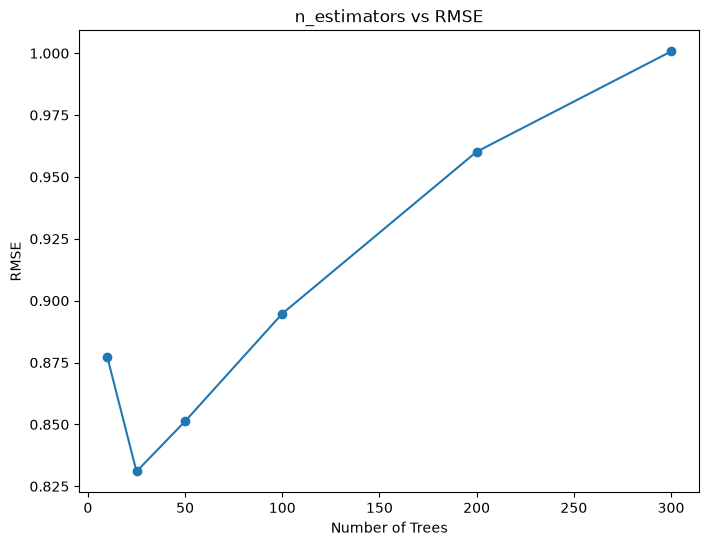

In [32]:
plt.figure(figsize=(8, 6))

plt.plot(
    results_df["n_estimators"],
    results_df["RMSE"],
    marker="o"
)

plt.xlabel("Number of Trees")
plt.ylabel("RMSE")
plt.title("n_estimators vs RMSE")

plt.show()

In [33]:
learning_rates = [
    0.01,
    0.05,
    0.1,
    0.2,
    0.3
]

learning_results = []

for lr in learning_rates:

    model_lr = GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=lr,
        max_depth=3,
        random_state=42
    )

    model_lr.fit(
        X_train,
        y_train
    )

    predictions = model_lr.predict(
        X_test
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    learning_results.append({
        "Learning_Rate": lr,
        "RMSE": rmse,
        "R2": r2
    })

learning_results_df = pd.DataFrame(
    learning_results
)

learning_results_df

,Learning_Rate,RMSE,R2
0,0.01,0.882763,0.376570
1,0.05,0.841161,0.433945
2,0.10,0.894765,0.359502
3,0.20,0.972733,0.243015
4,0.30,1.026539,0.156955


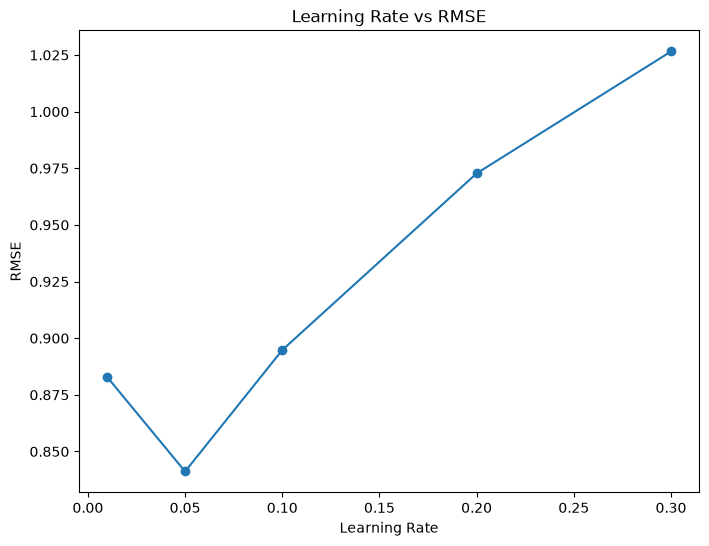

In [34]:
plt.figure(figsize=(8, 6))

plt.plot(
    learning_results_df["Learning_Rate"],
    learning_results_df["RMSE"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("RMSE")
plt.title("Learning Rate vs RMSE")

plt.show()

## Feature Importance

Gradient Boosting can calculate feature importance.

Feature importance shows how useful each feature was when building
the ensemble.

Higher importance means that the feature contributed more to the
model's predictions.

In [35]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance

,Feature,Importance
0,total_bill,0.915314
1,size,0.084686


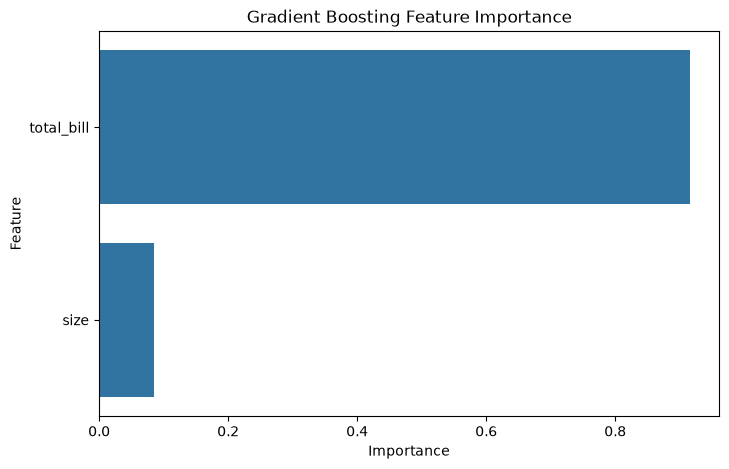

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Gradient Boosting Feature Importance")

plt.show()

In [37]:
new_data = pd.DataFrame({
    "total_bill": [50],
    "size": [3]
})

prediction = model.predict(
    new_data
)

print("Predicted Tip:", prediction[0])

Predicted Tip: 9.802086994631432


## Advantages of Gradient Boosting

- Excellent performance on many tabular datasets.
- Can model non-linear relationships.
- Can capture complex interactions between features.
- Does not require feature scaling.
- Provides feature importance.
- Often produces stronger predictions than a single Decision Tree.

## Disadvantages of Gradient Boosting

- Can overfit if not properly tuned.
- Training is sequential and can be slower than Random Forest.
- Hyperparameter tuning can be important.
- Less interpretable than a single Decision Tree.
- Sensitive to learning rate and number of estimators.